# 1) Descriptive data analysis


General Description: 
In this project, we will train our model on the ASVspoof 2019 dataset. This dataset contains two types of audio files: PAs (Physical Addresses) and LAs (Logical Addresses). We will use LAs for our project because they are AI-generated audio files. In this part, we will use two subsets provided with the dataset: `train` for model training and `dev` for validation and evaluation.

Data description: 
The audio files in the LA dataset are of two types: spoof (synthetic audio) and bonafide (real audio).
Training data is labeled in the file ASVspoof2019.LA.cm.train.trn.txt, and evaluation data in the file ASVspoof2019.LA.cm.dev.trl.txt. These files indicate for each audio file whether it is a real or synthetic recording.

Organization of step 1: we decided to separate our audio file loading and processing functions into a notebook src/data_utils.py to keep our step1 notebook clean.

In [1]:
import sys
from pathlib import Path

SRC_DIR = Path(r"C:\Users\norab\Documents\Cours_ESILV_A4\Machine Learning\deepfake-audio-project\src").resolve()
if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

from data_utils import load_asvspoof_protocol, attach_paths_by_utt
import pandas as pd
import matplotlib.pyplot as plt
DATA_ROOT = Path(r"C:\Users\norab\Documents\Cours_ESILV_A4\Machine Learning\deepfake-audio-project\archive\LA")
PROTO_TRAIN = DATA_ROOT / "ASVspoof2019_LA_cm_protocols" / "ASVspoof2019.LA.cm.train.trn.txt"
PROTO_DEV   = DATA_ROOT / "ASVspoof2019_LA_cm_protocols" / "ASVspoof2019.LA.cm.dev.trl.txt"
AUDIO_ROOT_TRAIN  = DATA_ROOT / "ASVspoof2019_LA_train" / "flac"
AUDIO_ROOT_DEV   = DATA_ROOT / "ASVspoof2019_LA_dev" / "flac"

train_df = attach_paths_by_utt(load_asvspoof_protocol(PROTO_TRAIN), AUDIO_ROOT_TRAIN)
dev_df   = attach_paths_by_utt(load_asvspoof_protocol(PROTO_DEV), AUDIO_ROOT_DEV)
print(train_df.head())

            utt  is_spoof                                               path
0  LA_T_1138215         0  C:\Users\norab\Documents\Cours_ESILV_A4\Machin...
1  LA_T_1271820         0  C:\Users\norab\Documents\Cours_ESILV_A4\Machin...
2  LA_T_1272637         0  C:\Users\norab\Documents\Cours_ESILV_A4\Machin...
3  LA_T_1276960         0  C:\Users\norab\Documents\Cours_ESILV_A4\Machin...
4  LA_T_1341447         0  C:\Users\norab\Documents\Cours_ESILV_A4\Machin...


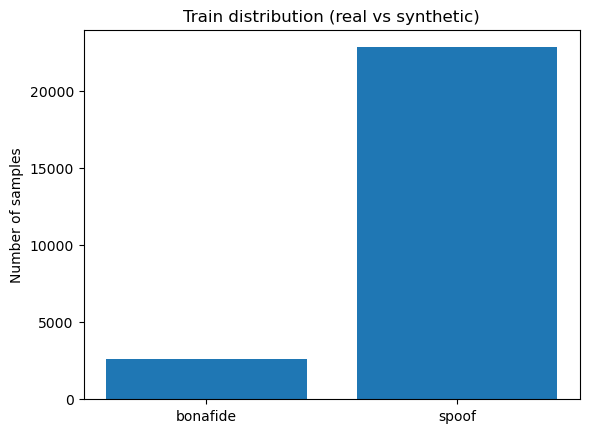

is_spoof
0     2580
1    22800
Name: count, dtype: int64
Total number of samples : 25380
Missing files : 0


In [2]:
counts = train_df["is_spoof"].value_counts().sort_index()

plt.bar(["bonafide", "spoof"], counts.values)
plt.title("Train distribution (real vs synthetic)")
plt.ylabel("Number of samples")
plt.show()

print(counts)
print("Total number of samples :", len(train_df))
print("Missing files :", train_df['path'].isna().sum())

We observe that our dataset is highly unbalanced; we could rebalance it, but in the dataset we have chosen, this imbalance is intentional in order to train our model correctly, so we will keep it as is for the first phase. 

# 2) Preprocessing

For preprocessing we do not extract all the audio files because it would take us too long, we will only extract 500 for training and 200 for evaluation.

In [3]:
import numpy as np
import librosa #Library used for processing audio files 
#(allows us to load .flac files and extract MFCC coefficients)

def extract_features(path, sr=16000, n_mfcc=13):
    y, _ = librosa.load(path, sr=sr) #loading of .flac files
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc) #Computing of MFCC coeficients 
    return np.concatenate([mfcc.mean(axis=1), mfcc.std(axis=1)]) #Concatenation of MFCC coefficients, means and standard deviations
# sample recovery
sample_train = train_df.sample(500, random_state=42)
sample_dev   = dev_df.sample(200, random_state=42)

#extraction of MFCC vectors for train and dev
X_train = np.vstack([extract_features(p) for p in sample_train["path"]])
y_train = sample_train["is_spoof"].to_numpy()

X_dev = np.vstack([extract_features(p) for p in sample_dev["path"]])
y_dev = sample_dev["is_spoof"].to_numpy()

print(X_train.shape, X_dev.shape)

#saving of MFCC
save_dir = Path(r"C:\Users\norab\Documents\Cours_ESILV_A4\Machine Learning\deepfake-audio-project\data")
save_dir.mkdir(exist_ok=True)

np.save(save_dir / "X_train_mfcc.npy", X_train)
np.save(save_dir / "y_train.npy", y_train)
np.save(save_dir / "X_dev_mfcc.npy", X_dev)
np.save(save_dir / "y_dev.npy", y_dev)


(500, 26) (200, 26)


# 3) Formalizing the problem
Our problem is a supervised binary classification problem.
The input is an audio clip that we convert into a vector of MFCC features.
The output is a binary label: 1 if spoofed, 0 otherwise.
We want a model capable of distinguishing spoofed audio from genuine audio.
We evaluate our model using the following metrics:
Accuracy: proportion of correct predictions.
AUC: quality of the separation between genuine and fake voices.

# 4) Basic Model
We decided to start with a classic approach using an SVM (Support Vector Machine) which will be trained on the mean MFCC coefficients and standard deviations of each sample.

In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.svm import SVC
from sklearn.metrics import roc_auc_score, accuracy_score, confusion_matrix

clf = make_pipeline(StandardScaler(), SVC(probability=True, kernel='rbf', C=2.0, gamma='scale'))
clf.fit(X_train, y_train)

y_pred = clf.predict(X_dev)
y_prob = clf.predict_proba(X_dev)[:, 1]

print("Accuracy :", accuracy_score(y_dev, y_pred))
print("AUC :", roc_auc_score(y_dev, y_prob))
print("Confusion matrix :\n", confusion_matrix(y_dev, y_pred))


Accuracy : 0.93
AUC : 0.9256114130434783
Confusion matrix :
 [[  4  12]
 [  2 182]]


Conclusion: we note that our model has a pro-spoof bias due to the significant imbalance in our dataset.